# 01 — Alberta extent + hand-off stack (Gate AB-0a, part i)

**Spec:** `spec/alberta_prioritization_spec.md` v0.4.1 (mirror of the y2y flagship v0.14.1);
methods_log **M2.1–M2.5**. Kernel `y2y-geo`. **Zero solves.**

What this builds, in order:

1. **The AB extent** (D-AB1): AB PU = parent PU ∩ Alberta polygon, centre-in-polygon cell rule —
   the same rule `gdal_rasterize` applied to the parent PA mask. The Y2Y-side boundary rule,
   including the parent's 20 km study-area buffer, is inherited through the parent PU; cells
   outside the unbuffered Y2Y boundary are **counted and disclosed, not removed**.
2. **The AB hand-off stack** `input_data/aligned_stack_ab/` = the parent stack **masked on the
   same grid** (no crop, no re-snap ⇒ cell IDs identical to the parent; C1 is a direct array
   comparison). Dust rule re-run against AB totals (spec §4), EFG drop rule re-applied (H-AB2),
   PA mask + climate realizations mirrored. Every parent module (`leverage_core`, `write_manifest`,
   `prioritizr_core.R`, `mga_core.R`) then runs unchanged via a `handoff_dir` / manifest pointer.
3. **Lock accounting + D-AB5**: the inherited 30%-total referent is checked for infeasibility
   FIRST; X is *derived* from the parent's own artifacts (realized fill rate of discretionary
   land, 0.1764), and the effective AB budget `(locked + X·unlocked)/N_ab` is frozen to
   `spec/ab_extent_v1.json` — every solve notebook applies it through `pr_override`.
4. The AB manifest (Python→R contract) + a cell-exactness proof.

Resumable: the stack build is skipped when `_build_meta.json` exists (`REBUILD = True` forces).

In [1]:
# ---- Setup: repo root, engines, paths ----------------------------------------------------------
import sys, pathlib, importlib, json, hashlib
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.io import MemoryFile
import rasterio.shutil as rio_shutil
import geopandas as gpd

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc
importlib.reload(config); importlib.reload(lc)

HERE = ROOT / "analyses" / "alberta_prioritization"
SPEC, FIGS, DATA = HERE / "spec", HERE / "figures", HERE / "data"
PARENT, AB = config.HANDOFF_DIR, config.AB_HANDOFF_DIR
for _d in (FIGS, DATA, AB, AB / "iucn_efg", AB / "climate_realizations"):
    _d.mkdir(parents=True, exist_ok=True)

REBUILD = False   # True re-writes aligned_stack_ab even if _build_meta.json exists

print(f"parent stack : {PARENT.relative_to(ROOT)}")
print(f"AB stack     : {AB.relative_to(ROOT)}")
print(f"dust rule    : share < {config.DUST_SHARE_MIN:g} of the AB feature total -> 0 (M2.3)")
print(f"parent budget: {config.BUDGET_PCT:.0%} of extent = the AUDIT convention; the AB SOLVE budget is set below (D-AB5)")

parent stack : input_data/aligned_stack
AB stack     : input_data/aligned_stack_ab
dust rule    : share < 1e-09 of the AB feature total -> 0 (M2.3)
parent budget: 30% of extent = the AUDIT convention; the AB SOLVE budget is set below (D-AB5)


## 1. The AB extent (D-AB1, M2.1)

Parent PU ∩ rasterized Alberta polygon. Both vectors are already ESRI:102008 (the grid CRS).

In [2]:
# ---- AB extent: parent PU ∩ Alberta polygon, centre-in-polygon rule ---------------------------
with rasterio.open(PARENT / "cost_uniform.tif") as src:
    PROF = dict(width=src.width, height=src.height, transform=src.transform, crs=src.crs)
    parent_pu = np.isfinite(src.read(1, masked=True).filled(np.nan))

ab_poly  = gpd.read_file(config.AB_BOUNDARY).to_crs(config.TARGET_CRS)
y2y_poly = gpd.read_file(config.CORRIDOR_REF).to_crs(config.TARGET_CRS)

def burn(gdf):
    a = rasterize([(g, 1) for g in gdf.geometry], out_shape=(PROF["height"], PROF["width"]),
                  transform=PROF["transform"], fill=0, all_touched=False, dtype="uint8")
    return a.astype(bool)

in_ab, in_y2y = burn(ab_poly), burn(y2y_poly)
AB_PU = parent_pu & in_ab
n_parent, n_ab = int(parent_pu.sum()), int(AB_PU.sum())
buffer_only = int((AB_PU & ~in_y2y).sum())
assert n_ab > 0 and not (AB_PU & ~parent_pu).any()

print(f"parent PU {n_parent:,} | AB PU {n_ab:,} = {100*n_ab/n_parent:.1f}% of the parent ({n_ab:,} km² at 1 km)")
print(f"  of which outside the UNBUFFERED Y2Y boundary (the inherited 20 km buffer): {buffer_only:,} cells "
      f"({100*buffer_only/n_ab:.1f}%) -- disclosed, kept (Y2Y-side rule inherited unchanged)")

# extent polygon for maps/provenance: Alberta ∩ the parent's buffered study area
sa = config.study_area(config.BUFFER_KM).to_crs(config.TARGET_CRS)
ext_poly = gpd.overlay(ab_poly[["geometry"]], sa[["geometry"]], how="intersection")
ext_poly.to_file(DATA / "ab_extent_v1.gpkg", driver="GPKG")
print(f"extent polygon -> {(DATA / 'ab_extent_v1.gpkg').relative_to(ROOT)}  ({ext_poly.area.sum()/1e6:,.0f} km² polygon area)")

parent PU 1,272,914 | AB PU 85,133 = 6.7% of the parent (85,133 km² at 1 km)
  of which outside the UNBUFFERED Y2Y boundary (the inherited 20 km buffer): 938 cells (1.1%) -- disclosed, kept (Y2Y-side rule inherited unchanged)
extent polygon -> analyses/alberta_prioritization/data/ab_extent_v1.gpkg  (109,249 km² polygon area)


## 2. The AB hand-off stack (M2.2–M2.4)

Mask → dust (AB totals) → COG, for every layer the parent stack carries: 9 continuous features
(`sl_soc` included, excluded downstream by the manifest exactly as in the parent), both climate
realizations, `cost_uniform`, `mask_protected_areas`, and the EFGs that still occur inside the AB PU.

In [3]:
# ---- Build the AB stack (skipped if already built) --------------------------------------------
def read_f32(path):
    with rasterio.open(path) as s:
        return s.read(1, masked=True).astype("float32").filled(np.nan)

def write_cog(path, arr, nodata, dtype):
    # Same COG recipe as 02_preprocess_align: in-memory GTiff -> CreateCopy to COG.
    ov = "nearest" if np.dtype(dtype) == np.uint8 else "average"
    prof = dict(driver="GTiff", count=1, dtype=dtype, nodata=nodata, **PROF)
    with MemoryFile() as mem:
        with mem.open(**prof) as tmp:
            tmp.write(np.asarray(arr).astype(dtype), 1)
            rio_shutil.copy(tmp, path, driver="COG", compress="DEFLATE",
                            overview_resampling=ov, BIGTIFF="IF_SAFER")

def sha(p):
    return hashlib.sha256(pathlib.Path(p).read_bytes()).hexdigest()

meta_path = AB / "_build_meta.json"
if meta_path.exists() and not REBUILD:
    META = json.loads(meta_path.read_text())
    print(f"AB stack already built {META['created_utc'][:19]}Z -- skipped (REBUILD=True to force)")
else:
    dust_log, hashes = {}, {}

    def mask_dust(name, a):
        out = np.where(AB_PU, a, np.nan).astype("float32")
        tot = float(np.nansum(out))
        dust = np.isfinite(out) & (out > 0) & (out < config.DUST_SHARE_MIN * tot)
        n, m = int(dust.sum()), float(np.nansum(out[dust]))
        out[dust] = 0.0
        share = m / tot if tot else 0.0
        assert share < 1e-4, f"{name}: dust rule dropped real mass ({share:.1e}) -- STOP and inspect"
        dust_log[name] = dict(cells=n, mass_share=share, ab_total=tot)
        return out

    cont = [k for k, c in config.DATASETS.items() if not c.get("multi")]
    for name in cont:
        src = PARENT / f"{name}.tif"
        hashes[name] = sha(src)
        write_cog(AB / f"{name}.tif", mask_dust(name, read_f32(src)), np.nan, "float32")
    for p in sorted((PARENT / "climate_realizations").glob("*.tif")):
        key = f"climate_realizations/{p.stem}"
        hashes[key] = sha(p)
        write_cog(AB / "climate_realizations" / p.name, mask_dust(key, read_f32(p)), np.nan, "float32")

    write_cog(AB / "cost_uniform.tif", np.where(AB_PU, 1.0, np.nan), np.nan, "float32")
    with rasterio.open(PARENT / "mask_protected_areas.tif") as s:
        pa = s.read(1)
    write_cog(AB / "mask_protected_areas.tif", np.where(AB_PU, pa, 255), 255, "uint8")
    hashes["mask_protected_areas"] = sha(PARENT / "mask_protected_areas.tif")

    for old in (AB / "iucn_efg").glob("*.tif"):
        old.unlink()                      # a re-run reflects the current drop list
    kept, dropped = [], []
    for p in sorted((PARENT / "iucn_efg").glob("*.tif")):
        with rasterio.open(p) as s:
            e = s.read(1)
        out = np.where(AB_PU, e, 255).astype("uint8")
        if int(((out == 1) | (out == 2)).sum()) == 0:
            dropped.append(p.stem)        # no occurrence inside the AB PU -> not a feature here
            continue
        write_cog(AB / "iucn_efg" / p.name, out, 255, "uint8")
        kept.append(p.stem)
        hashes[f"iucn_efg/{p.stem}"] = sha(p)

    META = dict(created_utc=datetime.now(timezone.utc).isoformat(), n_ab_pu=n_ab, n_parent_pu=n_parent,
                buffer_only_cells=buffer_only, dust_share_min=config.DUST_SHARE_MIN, dust=dust_log,
                efg_kept=kept, efg_dropped=dropped, parent_layer_sha256=hashes)
    meta_path.write_text(json.dumps(META, indent=1))
    print(f"wrote {len(cont)} continuous + 2 climate realizations + cost + PA mask + {len(kept)} EFGs -> {AB.relative_to(ROOT)}")

print("\ndust re-run against AB totals (M2.3):")
print(f"{'layer':<46}{'cells zeroed':>13}{'mass dropped':>14}")
for k, d in META["dust"].items():
    print(f"{k:<46}{d['cells']:13,}{d['mass_share']:14.2e}")
print(f"\nEFGs: {len(META['efg_kept'])} kept, {len(META['efg_dropped'])} dropped (no occurrence inside the AB PU) -- the H-AB2 contraction:")
for k in META["efg_dropped"]:
    print(f"   dropped  {k}")

wrote 9 continuous + 2 climate realizations + cost + PA mask + 27 EFGs -> input_data/aligned_stack_ab

dust re-run against AB totals (M2.3):
layer                                          cells zeroed  mass dropped
human_modification                                        0      0.00e+00
transboundary_connectivity                                0      0.00e+00
climate_corridors                                         0      0.00e+00
climate_type_macrorefugia                                 0      0.00e+00
irrecoverable_carbon_biomass                              0      0.00e+00
irrecoverable_carbon_m_soc                                0      0.00e+00
irrecoverable_carbon_sl_soc                               0      0.00e+00
aoh_richness_mammals                                      0      0.00e+00
aoh_richness_birds                                        0      0.00e+00
climate_realizations/macrorefugia_245_2071_2100            0      0.00e+00
climate_realizations/macrorefugia_585_2071_2

## 3. Lock accounting + D-AB5 (M2.5)

Order matters and is pre-registered: (1) the inherited 30%-total referent is tested for
infeasibility; (2) the factual protected share is read against the 30×30 lens; (3) X is derived
from the parent's artifacts; (4) the effective AB budget is frozen. The two superseded referents
are printed beside the anchor so the choice is visible, not buried.

In [4]:
# ---- Lock accounting: infeasibility check FIRST, then X derived from the parent -----------------
with rasterio.open(AB / "mask_protected_areas.tif") as s:
    locked_ab = (s.read(1) == 1) & AB_PU
with rasterio.open(PARENT / "mask_protected_areas.tif") as s:
    locked_par = (s.read(1) == 1) & parent_pu
n_lock_ab, n_lock_par = int(locked_ab.sum()), int(locked_par.sum())

# the parent's realized behaviour (must reproduce results_log R0 / run_summary.json exactly)
assert n_parent == 1_272_914 and n_lock_par == 191_029, (n_parent, n_lock_par)
par_budget   = int(round(config.BUDGET_PCT * n_parent))          # 381,874
par_disc     = n_parent - n_lock_par                              # 1,081,885
par_disc_sel = par_budget - n_lock_par                            # 190,845
X = par_disc_sel / par_disc                                       # 0.1764 = realized fill rate of discretionary land
print(f"PARENT: PU {n_parent:,} | locked {n_lock_par:,} ({100*n_lock_par/n_parent:.1f}%) | budget {par_budget:,} | "
      f"discretionary {par_disc:,}, selected {par_disc_sel:,}  ->  X = {X:.4f}")

inherited_budget = int(round(config.BUDGET_PCT * n_ab))
n_unlocked = n_ab - n_lock_ab
print(f"\nAB: PU {n_ab:,} | locked {n_lock_ab:,} = {100*n_lock_ab/n_ab:.1f}% of the AB extent  "
      f"[30x30 lens: {'AT OR ABOVE 30% -- headline for Tim' if n_lock_ab >= 0.30 * n_ab else 'below 30%'}]")
if n_lock_ab > inherited_budget:
    print(f"  inherited 30%-total referent: budget {inherited_budget:,} < locked -> INFEASIBLE (lb=1 exceeds RHS); D-AB5 escalation fires")
else:
    print(f"  inherited 30%-total referent: feasible; additions would be only "
          f"{inherited_budget - n_lock_ab:,} cells ({100*(inherited_budget - n_lock_ab)/n_ab:.1f}% of extent)")

opts = {"X = parent fill rate (ANCHOR, v0.4)": n_lock_ab + X * n_unlocked,
        "15% of unlocked (v0.3, superseded)":  n_lock_ab + 0.15 * n_unlocked,
        "15% of TOTAL extent":                  n_lock_ab + 0.15 * n_ab}
print("\nD-AB5 additions referents  (budget = locked + additions):")
for k, b in opts.items():
    add = b - n_lock_ab
    print(f"  {k:<40} budget {b:9,.0f} cells = {100*b/n_ab:5.1f}% of extent | additions {add:8,.0f} km² = {100*add/n_ab:4.1f}% of extent")

budget_cells = int(round(n_lock_ab + X * n_unlocked))
EXTENT = dict(
    extent_id="ab_y2y_v1", mirror_spec_version="v0.14.1",
    n_pu=n_ab, n_locked=n_lock_ab, locked_share=n_lock_ab / n_ab, n_unlocked=n_unlocked,
    buffer_only_cells=buffer_only,
    budget_semantics="locked + X * unlocked (additions semantics, D-AB5)",
    x_of_unlocked=X,
    x_source=f"parent realized fill rate ({par_budget} - {n_lock_par}) / ({n_parent} - {n_lock_par})",
    budget_cells=budget_cells, budget_pct_effective=budget_cells / n_ab,
    additions_cells=budget_cells - n_lock_ab,
    inherited_30pct_budget_cells=inherited_budget, inherited_30pct_feasible=bool(n_lock_ab <= inherited_budget),
    parent=dict(n_pu=n_parent, n_locked=n_lock_par, budget_cells=par_budget, discretionary=par_disc),
    created_utc=datetime.now(timezone.utc).isoformat())
(SPEC / "ab_extent_v1.json").write_text(json.dumps(EXTENT, indent=1))
print(f"\nFROZEN -> spec/ab_extent_v1.json: budget_pct_effective = {EXTENT['budget_pct_effective']:.4f} "
      f"({budget_cells:,} cells = locked {n_lock_ab:,} + additions {budget_cells - n_lock_ab:,})")

PARENT: PU 1,272,914 | locked 191,029 (15.0%) | budget 381,874 | discretionary 1,081,885, selected 190,845  ->  X = 0.1764

AB: PU 85,133 | locked 27,972 = 32.9% of the AB extent  [30x30 lens: AT OR ABOVE 30% -- headline for Tim]
  inherited 30%-total referent: budget 25,540 < locked -> INFEASIBLE (lb=1 exceeds RHS); D-AB5 escalation fires

D-AB5 additions referents  (budget = locked + additions):
  X = parent fill rate (ANCHOR, v0.4)      budget    38,055 cells =  44.7% of extent | additions   10,083 km² = 11.8% of extent
  15% of unlocked (v0.3, superseded)       budget    36,546 cells =  42.9% of extent | additions    8,574 km² = 10.1% of extent
  15% of TOTAL extent                      budget    40,742 cells =  47.9% of extent | additions   12,770 km² = 15.0% of extent

FROZEN -> spec/ab_extent_v1.json: budget_pct_effective = 0.4470 (38,055 cells = locked 27,972 + additions 10,083)


## 4. AB manifest + cell-exactness proof

`config.write_manifest(analysis="ab_y2y", handoff_dir=AB, …)` writes the Python→R contract for
the AB stack. The manifest carries the parent's 30% as the documented baseline; every solve
notebook overrides it with `budget_pct_effective`. Then the proof: on the AB PU, every AB layer
equals the parent layer except the cells the AB dust rule zeroed.

In [5]:
# ---- Manifest + proof ----------------------------------------------------------------------------
mp = config.write_manifest(analysis="ab_y2y", handoff_dir=AB, manifest_path=AB / "manifest.json")
man = json.loads(pathlib.Path(mp).read_text())
par = json.loads((PARENT / "manifest.json").read_text())
assert man["grid"] == par["grid"], "AB grid differs from the parent grid -- STOP"
n_cont = sum(l["role"] == "feature_continuous" for l in man["layers"])
n_efg  = sum(l["role"] == "feature_efg" for l in man["layers"])
print(f"manifest -> {pathlib.Path(mp).relative_to(ROOT)} | grid identical to the parent | "
      f"{n_cont} continuous + {n_efg} EFG features | manifest budget_pct {man['params']['budget_pct']} "
      f"(baseline; solves override to {EXTENT['budget_pct_effective']:.4f})")

pu_ab = lc.pu_mask(AB)
assert int(pu_ab.sum()) == n_ab, "PU from the AB cost layer != AB_PU"
for name in ("irrecoverable_carbon_m_soc", "irrecoverable_carbon_biomass", "climate_type_macrorefugia"):
    a, p = read_f32(AB / f"{name}.tif"), read_f32(PARENT / f"{name}.tif")
    diff = pu_ab & ~np.isclose(a, p, rtol=0, atol=0, equal_nan=True)
    print(f"  {name:<32} {int(diff.sum()):>7,} cells differ from the parent on the AB PU "
          f"(AB dust-zeroed: {META['dust'][name]['cells']:,})")
    assert int(diff.sum()) == META["dust"][name]["cells"]
print("cell-exactness PROVEN: AB stack == parent stack on the AB grid subset, up to the AB dust rule (D-AB1)")

manifest -> input_data/aligned_stack_ab/manifest.json | grid identical to the parent | 8 continuous + 27 EFG features | manifest budget_pct 0.3 (baseline; solves override to 0.4470)
  irrecoverable_carbon_m_soc             0 cells differ from the parent on the AB PU (AB dust-zeroed: 0)
  irrecoverable_carbon_biomass           0 cells differ from the parent on the AB PU (AB dust-zeroed: 0)
  climate_type_macrorefugia              0 cells differ from the parent on the AB PU (AB dust-zeroed: 0)
cell-exactness PROVEN: AB stack == parent stack on the AB grid subset, up to the AB dust rule (D-AB1)


wrote analyses/alberta_prioritization/figures/ab_extent.png


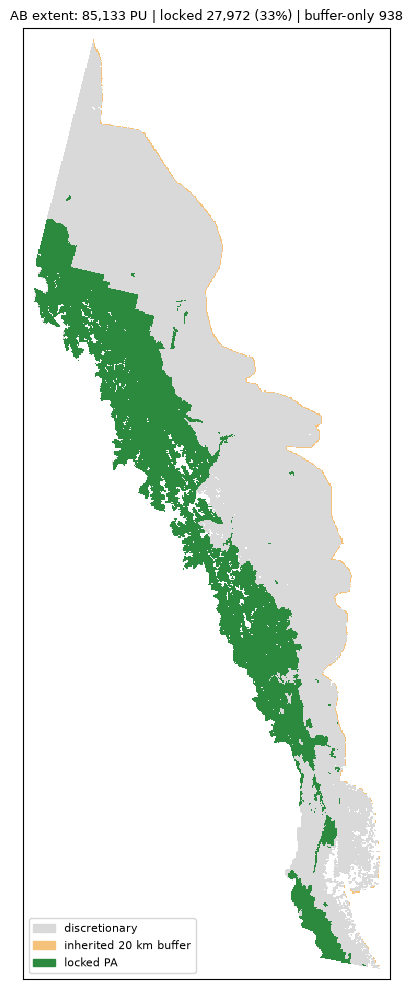

In [6]:
# ---- Extent map -> figures/ab_extent.png ------------------------------------------------------------
import matplotlib.pyplot as plt
rows = np.where(AB_PU.any(axis=1))[0]; cols = np.where(AB_PU.any(axis=0))[0]
r0, r1, c0, c1 = rows.min() - 10, rows.max() + 10, cols.min() - 10, cols.max() + 10
img = np.full(AB_PU.shape, np.nan, "float32")
img[AB_PU] = 1.0                      # discretionary
img[AB_PU & ~in_y2y] = 2.0            # inherited-buffer cells (outside the unbuffered Y2Y boundary)
img[locked_ab] = 3.0                  # locked PAs
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(img[r0:r1, c0:c1], cmap=plt.matplotlib.colors.ListedColormap(["#d9d9d9", "#f4c27a", "#2b8a3e"]),
          vmin=1, vmax=3, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"AB extent: {n_ab:,} PU | locked {n_lock_ab:,} ({100*n_lock_ab/n_ab:.0f}%) | buffer-only {buffer_only:,}", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#d9d9d9", label="discretionary"), Patch(color="#f4c27a", label="inherited 20 km buffer"),
                   Patch(color="#2b8a3e", label="locked PA")], loc="lower left", fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "ab_extent.png", dpi=180)
print("wrote", (FIGS / "ab_extent.png").relative_to(ROOT))

## → next: `02_ab0a_audit.ipynb`

Results to enter in `spec/results_log.md` (R1) after this runs: AB PU count and km², buffer-only
count, per-layer dust drops, EFG drop list (H-AB2 first reading), locked count/share and the
30×30 verdict, inherited-referent feasibility, X and the effective budget.